In [173]:
#!pip install scikit-learn

In [103]:
import pandas as pd
import datetime as dt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np
from datetime import datetime

In [74]:
#Import the forecast results data
df_results = pd.read_csv(r'D:\Modelling\demandcast\demandcast\ml_models\results\forecasts\with_xgboost_model_20260525_160336\using_assembled_data_for_forecasting_20260525_160601\all_20260525_160821.csv')

In [75]:
#Import the training (original) data
df_train = pd.read_csv(r'D:\Modelling\demandcast\demandcast\data\assembled\assembled_data_for_training_20260525_154050_real_data.csv')

In [76]:
df_results = df_results[df_results['Entity code']=='PHL']
df_train = df_train[df_train['Entity code']=='PHL']

In [77]:
df_train = df_train[['Time (UTC)','Entity code','Load (MW)']]

#Only keep the 2024 - 2025 training values 
df_train = df_train[(df_train['Time (UTC)'] >= '2023-12-31') & (df_train['Time (UTC)']<= '2026-01-02')].reset_index(drop = True)

In [78]:
df_train

,Time (UTC),Entity code,Load (MW)
0,2023-12-31 03:00:00,PHL,11174.030762
1,2023-12-31 04:00:00,PHL,11393.137207
2,2023-12-31 05:00:00,PHL,11618.604126
3,2023-12-31 07:00:00,PHL,12077.119873
4,2023-12-31 14:00:00,PHL,11577.092773
...,...,...,...
17555,2025-12-31 08:00:00,PHL,12475.103028
17556,2025-12-31 09:00:00,PHL,12628.034546
17557,2025-12-31 11:00:00,PHL,13077.724610
17558,2025-12-31 13:00:00,PHL,11948.861816


In [79]:
df_results = df_results[['Time (UTC)','Entity code','Forecast load (MW)']]

In [80]:
df_results

,Time (UTC),Entity code,Forecast load (MW)
0,2023-12-31 16:00:00,PHL,13106.864210
1,2024-01-01 01:00:00,PHL,15482.477255
2,2024-01-01 03:00:00,PHL,16548.372402
3,2024-01-01 05:00:00,PHL,16212.335660
4,2024-01-01 07:00:00,PHL,16920.298349
...,...,...,...
29314,2025-12-31 02:00:00,PHL,14927.020631
29315,2025-12-31 03:00:00,PHL,15123.715730
29316,2025-12-31 04:00:00,PHL,14974.763775
29317,2025-12-31 06:00:00,PHL,15302.136990


In [81]:
df_results['Time (UTC)'] = pd.to_datetime(df_results['Time (UTC)'])
df_train['Time (UTC)'] = pd.to_datetime(df_train['Time (UTC)'])

In [82]:
df = pd.merge(df_train, df_results, on = ['Time (UTC)','Entity code'],how = 'left')

In [83]:
df = df.dropna()

In [84]:
df['Load (MW)']=pd.to_numeric(df['Load (MW)'])

In [85]:
df['Forecast load (MW)']=pd.to_numeric(df['Forecast load (MW)'])

In [86]:
df['Time (LOCAL)'] = df['Time (UTC)'].dt.tz_localize('UTC').dt.tz_convert('Asia/Singapore')

In [87]:
df = df.reset_index()

In [88]:
df

,index,Time (UTC),Entity code,Load (MW),Forecast load (MW),Time (LOCAL)
0,5,2023-12-31 17:00:00,PHL,10840.745605,12195.081427,2024-01-01 01:00:00+08:00
1,6,2023-12-31 18:00:00,PHL,10555.134766,11779.152107,2024-01-01 02:00:00+08:00
2,7,2024-01-01 02:00:00,PHL,9530.948608,16074.491314,2024-01-01 10:00:00+08:00
3,8,2024-01-01 03:00:00,PHL,9961.350219,16548.372402,2024-01-01 11:00:00+08:00
4,9,2024-01-01 05:00:00,PHL,10449.731812,16212.335660,2024-01-01 13:00:00+08:00
...,...,...,...,...,...,...
17539,17555,2025-12-31 08:00:00,PHL,12475.103028,15196.113686,2025-12-31 16:00:00+08:00
17540,17556,2025-12-31 09:00:00,PHL,12628.034546,15032.640368,2025-12-31 17:00:00+08:00
17541,17557,2025-12-31 11:00:00,PHL,13077.724610,14889.295883,2025-12-31 19:00:00+08:00
17542,17558,2025-12-31 13:00:00,PHL,11948.861816,14466.313363,2025-12-31 21:00:00+08:00


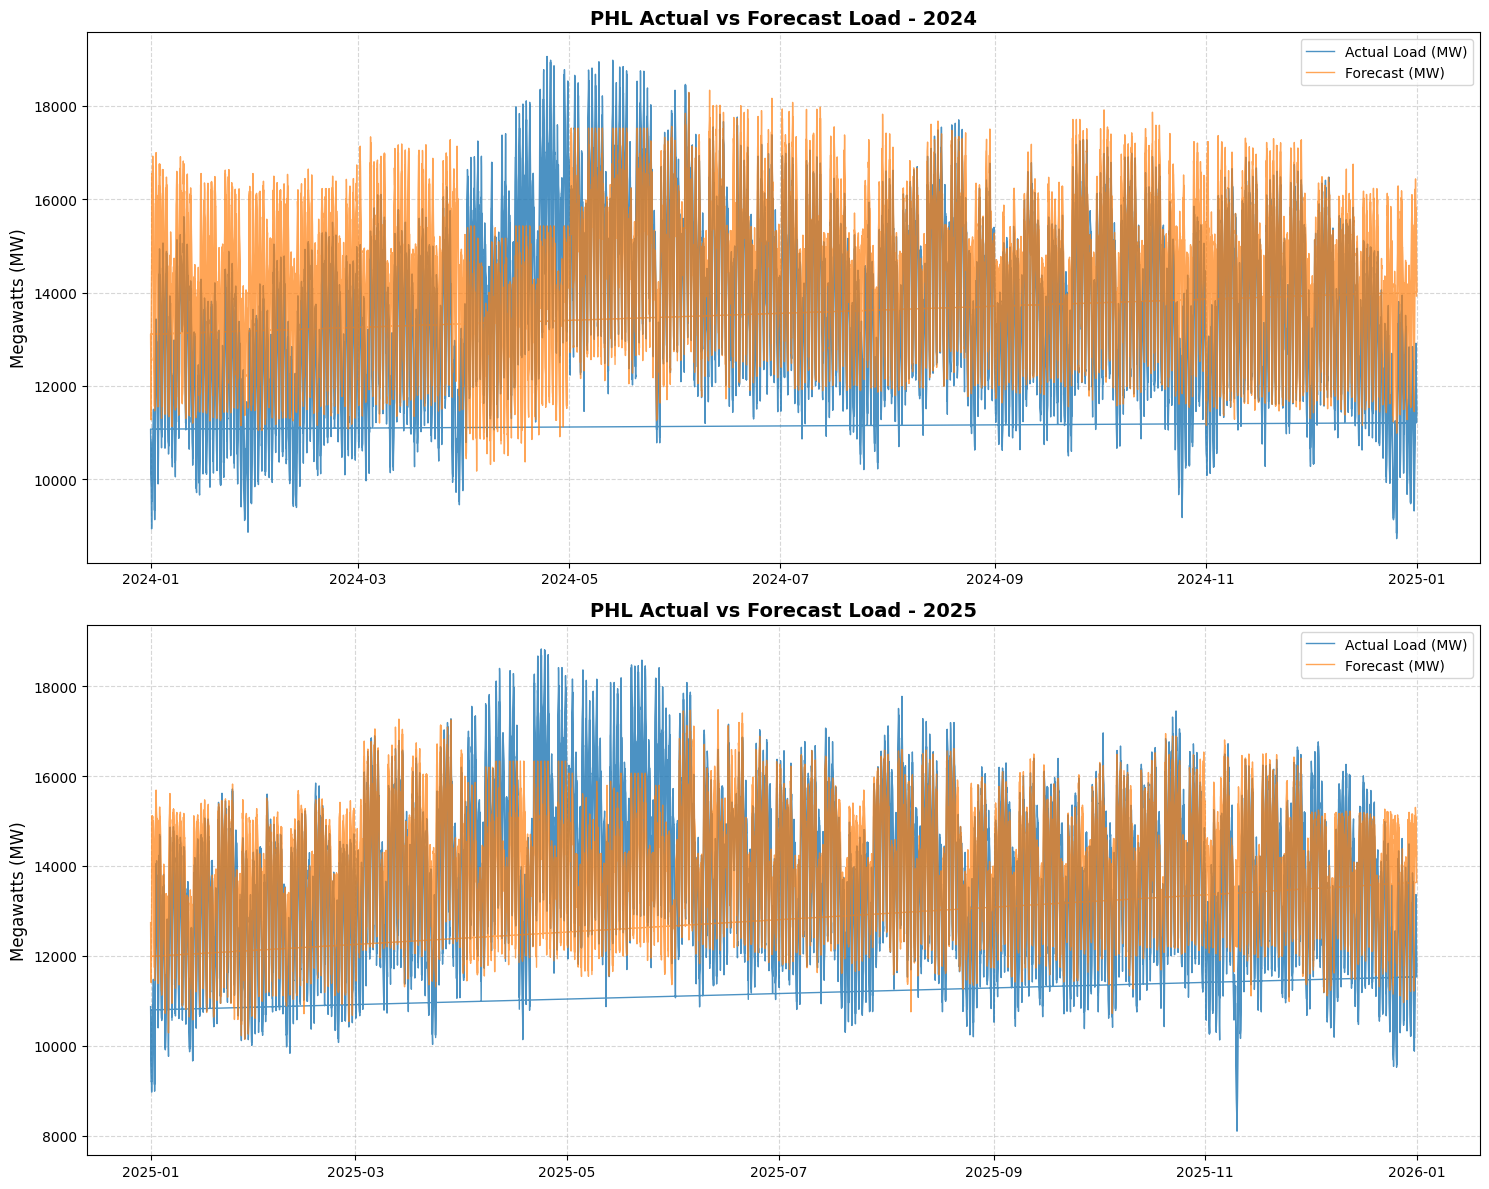

In [113]:
#Create the comparison graph
import matplotlib.pyplot as plt
from datetime import datetime 

df['Time (LOCAL)'] = pd.to_datetime(df['Time (LOCAL)'])

df['Year'] = df['Time (LOCAL)'].dt.year
years = sorted(df['Year'].unique())

fig, axes = plt.subplots(nrows=len(years), ncols=1, figsize=(15, 6 * len(years)), sharex=False)

if len(years) == 1:
    axes = [axes]

for i, year in enumerate(years):
    # Filter data for the specific year
    yearly_data = df[df['Year'] == year]
    
    # Plot Actual Load (Blue)
    axes[i].plot(yearly_data['Time (LOCAL)'], yearly_data['Load (MW)'], 
                 label='Actual Load (MW)', color='#1f77b4', alpha=0.8, linewidth=1)
    
    # Plot Forecast Load (Red/Orange)
    axes[i].plot(yearly_data['Time (LOCAL)'], yearly_data['Forecast load (MW)'], 
                 label='Forecast (MW)', color='#ff7f0e', alpha=0.7, linewidth=1)
    
    # Formatting
    entity = df['Entity code'].unique().item()
    axes[i].set_title(f'{entity} Actual vs Forecast Load - {year}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Megawatts (MW)', fontsize=12)
    axes[i].legend(loc='upper right')
    axes[i].grid(True, linestyle='--', alpha=0.5)

# Adjust layout to prevent overlapping text
plt.tight_layout()
# Save the high-resolution image to your folder
time_current = datetime.now().strftime('%Y%m%d-%H%M%S')
plt.savefig(f"Actual_vs_Forecast_{entity}_{time_current}.png", dpi=300)
plt.show()

In [114]:
# Error metrics

y_true = df['Load (MW)']
y_pred = df['Forecast load (MW)']

# Calculations
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse) # Or root_mean_squared_error(y_true, y_pred) in newer versions
mape = mean_absolute_percentage_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

# Displaying results
print(f"MSE:  {mse:.2f} MW")
print(f"RMSE: {rmse:.2f} MW")
print(f"MAPE: {mape * 100:.2f}%")
print(f"R2 Score: {r2:.4f}")

MSE:  1334409.28 MW
RMSE: 1155.17 MW
MAPE: 6.73%
R2 Score: 0.6331
